# GraphCAG Pipeline Companion Notebook

This notebook is a visual companion to the GraphCAG paper. It is designed to make the system easier to understand at a glance: what flows through the pipeline, where graph structure actually enters the decision process, how RAPID routes requests across L0, L1, and L2, and what the Stage 1 and Stage 1.5 evidence means.

The notebook is intentionally not a full benchmark runner. Instead, it turns the paper into diagrams, small tables, and charts so the controller logic is visible before readers dive into the implementation.

## What This Notebook Shows

1. The three-layer GraphCAG architecture.
2. The online request workflow from input to response.
3. The grouped state schema carried by the LangGraph pipeline.
4. The RAPID routing policy and where PCC / reuse risk is applied.
5. The empirical picture from the paper: Stage 1 workload latency and Stage 1.5 drift probes.
6. A compact walkthrough of exact hit, safe near-hit, and unsafe drift cases.

In [8]:
import math
from textwrap import fill

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

try:
    import pandas as pd
except ImportError:
    pd = None

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11

COLORS = {
    'orchestration': '#1f3a5f',
    'core': '#2e8b57',
    'tools': '#c97b2a',
    'l0': '#2f80ed',
    'l1': '#27ae60',
    'l2': '#d35454',
    'neutral': '#6c757d',
    'accent': '#8e44ad'
}

def rounded_box(ax, xy, width, height, text, fc, ec='black', text_color='white', fontsize=11):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y), width, height,
        boxstyle='round,pad=0.02,rounding_size=0.03',
        linewidth=1.5, facecolor=fc, edgecolor=ec
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, y + height / 2, text, ha='center', va='center', color=text_color, fontsize=fontsize, wrap=True)
    return patch

def arrow(ax, start, end, color='#333333', style='-|>', lw=1.8, connectionstyle='arc3,rad=0.0'):
    patch = FancyArrowPatch(start, end, arrowstyle=style, mutation_scale=14, linewidth=lw, color=color, connectionstyle=connectionstyle)
    ax.add_patch(patch)
    return patch

In [9]:
workload_benchmarks = [
    {'workload': 'Wi+Locness', 'baseline_ms': 177.3, 'graphcag_ms': 100.1},
    {'workload': 'Grammar', 'baseline_ms': 116.1, 'graphcag_ms': 61.3},
    {'workload': 'Dialogue', 'baseline_ms': 134.1, 'graphcag_ms': 77.7},
    {'workload': 'Fluency', 'baseline_ms': 131.0, 'graphcag_ms': 74.3},
]

probe_results = [
    {'probe': 'exact_repeat', 'category': 'safe_repeat', 'layer': 'L0', 'decision': 'reuse', 'rho': 0.25, 'latency_ms': 4},
    {'probe': 'case_trim_variant', 'category': 'benign_surface', 'layer': 'L0', 'decision': 'reuse', 'rho': 0.25, 'latency_ms': 4},
    {'probe': 'internal_whitespace_variant', 'category': 'benign_surface', 'layer': 'L1', 'decision': 'patch', 'rho': 0.250007, 'latency_ms': 5},
    {'probe': 'punctuation_variant', 'category': 'benign_surface', 'layer': 'L1', 'decision': 'patch', 'rho': 0.250008, 'latency_ms': 5},
    {'probe': 'polite_wrapper_variant', 'category': 'wrapper_surface', 'layer': 'none', 'decision': 'full', 'rho': 1.0, 'latency_ms': 71},
    {'probe': 'intent_explain_variant', 'category': 'intent_shift', 'layer': 'none', 'decision': 'full', 'rho': 1.0, 'latency_ms': 69},
    {'probe': 'intent_practice_variant', 'category': 'intent_shift', 'layer': 'none', 'decision': 'full', 'rho': 1.0, 'latency_ms': 68},
    {'probe': 'cross_level_variant', 'category': 'profile_shift', 'layer': 'none', 'decision': 'full', 'rho': 1.0, 'latency_ms': 71},
]

state_groups = {
    'Input': ['user_input', 'session_id', 'user_id', 'input_type'],
    'Learner Context': ['learner_profile', 'conversation_history'],
    'Knowledge Graph': ['kg_seed_concepts', 'kg_expanded_nodes', 'kg_paths'],
    'Diagnosis': ['diagnosis_intent', 'diagnosis_errors', 'diagnosis_root_causes', 'diagnosis_confidence'],
    'Retrieval': ['vector_hits', 'retrieved_context', 'retrieval_trace'],
    'Generation': ['tutor_response', 'strategy', 'next_action'],
    'Scores': ['fluency_score', 'grammar_score', 'vocabulary_level', 'overall_score'],
    'Cache Control': ['cache_fingerprint', 'cache_decision', 'cache_layer', 'cache_bucket', 'reuse_risk', 'cache_hit'],
    'Metadata': ['models_used', 'latency_ms', 'path', 'error']
}

risk_components = [
    ('Intent mismatch ΔI', 0.30),
    ('Concept mismatch ΔC', 0.25),
    ('Level drift Δℓ', 0.20),
    ('Progress drift Δprog', 0.10),
    ('Staleness s', 0.15),
]

stage_summary = [
    ('Stage 1', 'L0 deterministic workloads', 'Measures pipeline overhead under conservative exact reuse'),
    ('Stage 1.5', 'L1 controlled drift probes', 'Validates graph-aware near-hit reuse and PCC rejection boundaries'),
    ('Stage 2', 'L1 coverage benchmark', 'Scales near-hit evaluation to paraphrase-rich workloads'),
    ('Stage 3', 'Graph-local artifact expansion', 'Moves toward reusable prompt packages and decoder-state units'),
]

pipeline_nodes = [
    ('input', 'Input Node', 'orchestration'),
    ('profile', 'Profile Load', 'orchestration'),
    ('cache_gate', 'RAPID Cache Gate', 'core'),
    ('l0', 'L0 Exact Reuse', 'l0'),
    ('l1', 'L1 Near-Hit Patch', 'l1'),
    ('kg_expand', 'KG Expand', 'core'),
    ('diagnose', 'Diagnose', 'core'),
    ('retrieve', 'Hybrid Retrieve', 'core'),
    ('generate', 'Grounded Generate', 'core'),
    ('respond', 'Respond', 'tools'),
]

pipeline_edges = [
    ('input', 'profile'),
    ('profile', 'cache_gate'),
    ('cache_gate', 'l0'),
    ('cache_gate', 'l1'),
    ('cache_gate', 'kg_expand'),
    ('kg_expand', 'diagnose'),
    ('diagnose', 'retrieve'),
    ('retrieve', 'generate'),
    ('l0', 'respond'),
    ('l1', 'respond'),
    ('generate', 'respond'),
]

sample_traces = [
    {
        'case': 'Exact repeat',
        'query': 'Correct this sentence: She go to school yesterday.',
        'path_nodes': ['input', 'profile', 'cache_gate', 'l0', 'respond'],
        'cache_layer': 'L0',
        'decision': 'reuse',
        'rho': 0.25,
        'latency_ms': 4,
        'note': 'Exact normalized key hit.'
    },
    {
        'case': 'Whitespace drift',
        'query': 'Correct  this  sentence:  She  go  to  school  yesterday.',
        'path_nodes': ['input', 'profile', 'cache_gate', 'l1', 'respond'],
        'cache_layer': 'L1',
        'decision': 'patch',
        'rho': 0.250007,
        'latency_ms': 5,
        'note': 'L0 miss, graph bucket match, safe patch.'
    },
    {
        'case': 'Intent shift',
        'query': 'Explain why "She go to school yesterday" is wrong.',
        'path_nodes': ['input', 'profile', 'cache_gate', 'kg_expand', 'diagnose', 'retrieve', 'generate', 'respond'],
        'cache_layer': 'none',
        'decision': 'full',
        'rho': 1.0,
        'latency_ms': 69,
        'note': 'PCC rejects reuse because intent drift is unsafe.'
    },
]

sample_state_rows = [
    {'node': 'input', 'state_update': 'user_input, session_id, input_type', 'sample_value': 'B1 correction request'},
    {'node': 'profile', 'state_update': 'learner_profile, conversation_history', 'sample_value': 'level=B1, sessions_completed=12'},
    {'node': 'cache_gate', 'state_update': 'cache_fingerprint, cache_decision, cache_layer, reuse_risk', 'sample_value': 'intent=unknown, bucket=sv_agreement|B1'},
    {'node': 'kg_expand', 'state_update': 'kg_seed_concepts, kg_expanded_nodes', 'sample_value': 'subject_verb_agreement, past_tense_marker'},
    {'node': 'diagnose', 'state_update': 'diagnosis_intent, diagnosis_errors, diagnosis_confidence', 'sample_value': 'correct, tense+agreement, 0.94'},
    {'node': 'retrieve', 'state_update': 'retrieved_context, retrieval_trace', 'sample_value': 'grammar snippets + examples'},
    {'node': 'generate', 'state_update': 'tutor_response, strategy, overall_score', 'sample_value': 'scaffolded correction response'},
    {'node': 'respond', 'state_update': 'latency_ms, path, models_used', 'sample_value': 'fast or slow response path'},
]

if pd is not None:
    workload_df = pd.DataFrame(workload_benchmarks)
    probe_df = pd.DataFrame(probe_results)
    trace_df = pd.DataFrame(sample_traces)
    state_df = pd.DataFrame(sample_state_rows)
else:
    workload_df = workload_benchmarks
    probe_df = probe_results
    trace_df = sample_traces
    state_df = sample_state_rows

print('Loaded paper-aligned benchmark snapshots and sample node traces for notebook visualizations.')

Loaded paper-aligned benchmark snapshots and sample node traces for notebook visualizations.


## 1. GraphCAG as a Three-Layer System

The paper frames GraphCAG as a layered controller, not just a graph retriever. The graph matters because it organizes reusable inference units and narrows candidate reuse before full reconstruction.

The high-level split is:
- **Orchestration layer**: LangGraph workflow, state transitions, logging.
- **GraphCAG core layer**: L0 exact reuse, L1 graph-aware near-hit reuse, L2 graph-grounded reconstruction.
- **Model and tool layer**: generators, speech tools, vector retrieval, storage backends.

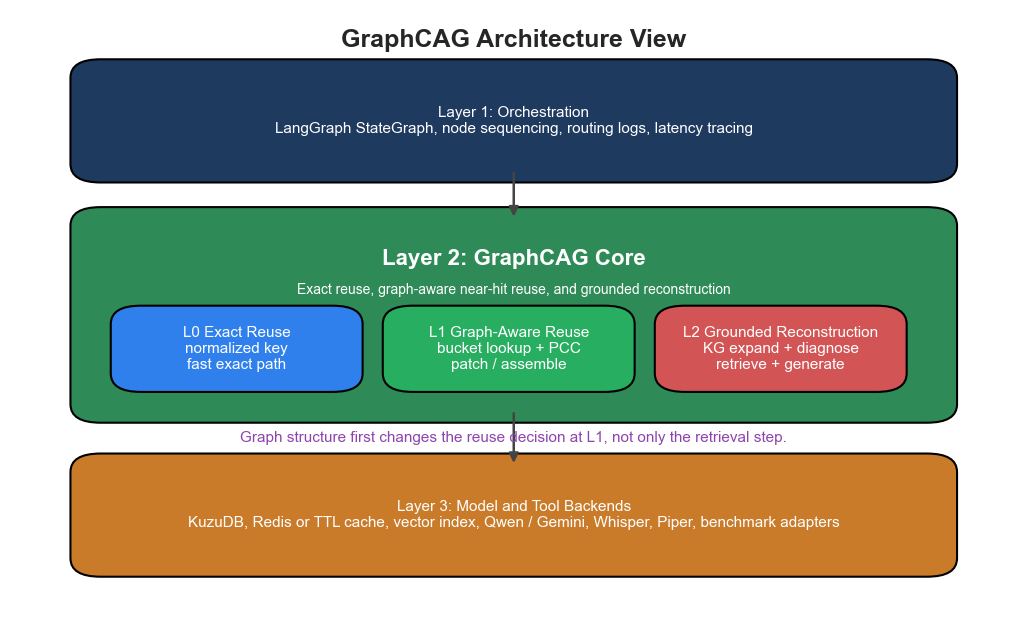

In [7]:
fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

rounded_box(ax, (0.08, 0.74), 0.84, 0.16, 'Layer 1: Orchestration\nLangGraph StateGraph, node sequencing, routing logs, latency tracing', COLORS['orchestration'])
rounded_box(ax, (0.08, 0.35), 0.84, 0.31, '', COLORS['core'])
ax.text(0.5, 0.595, 'Layer 2: GraphCAG Core', ha='center', va='center', fontsize=16, fontweight='bold', color='white')
ax.text(0.5, 0.545, 'Exact reuse, graph-aware near-hit reuse, and grounded reconstruction', ha='center', va='center', fontsize=10, color='white')
rounded_box(ax, (0.12, 0.40), 0.21, 0.10, 'L0 Exact Reuse\nnormalized key\nfast exact path', COLORS['l0'])
rounded_box(ax, (0.39, 0.40), 0.21, 0.10, 'L1 Graph-Aware Reuse\nbucket lookup + PCC\npatch / assemble', COLORS['l1'])
rounded_box(ax, (0.66, 0.40), 0.21, 0.10, 'L2 Grounded Reconstruction\nKG expand + diagnose\nretrieve + generate', COLORS['l2'])
rounded_box(ax, (0.08, 0.10), 0.84, 0.16, 'Layer 3: Model and Tool Backends\nKuzuDB, Redis or TTL cache, vector index, Qwen / Gemini, Whisper, Piper, benchmark adapters', COLORS['tools'])

arrow(ax, (0.50, 0.74), (0.50, 0.66), color='#444444')
arrow(ax, (0.50, 0.35), (0.50, 0.26), color='#444444')

ax.text(0.5, 0.95, 'GraphCAG Architecture View', ha='center', va='center', fontsize=18, fontweight='bold')
ax.text(0.5, 0.305, 'Graph structure first changes the reuse decision at L1, not only the retrieval step.', ha='center', va='center', fontsize=11, color=COLORS['accent'])
plt.show()

## 2. Online Request Workflow

A reader usually understands GraphCAG better when it is read as an online routing process:

1. Read the request and active learner state.
2. Build a cheap fingerprint.
3. Try the cheapest safe reuse path first.
4. Escalate only when reuse is absent or unsafe.

This is the controller logic the paper calls **RAPID-GraphCAG**.

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

steps = [
    (0.02, 'Input + profile\nquery, level, session'),
    (0.17, 'Cheap fingerprint\nintent, level, concept seed'),
    (0.32, 'L0 exact key\nnormalized text + level'),
    (0.49, 'L1 graph bucket\nconcept-state neighborhood'),
    (0.66, 'PCC + risk check\nrank valid candidates'),
    (0.83, 'L2 reconstruction\nKG -> diagnosis -> retrieval -> generation'),
]

for x, label in steps:
    rounded_box(ax, (x, 0.38), 0.13, 0.22, fill(label, 18), COLORS['neutral'], text_color='white', fontsize=10)

for i in range(len(steps) - 1):
    x1 = steps[i][0] + 0.13
    x2 = steps[i + 1][0]
    arrow(ax, (x1, 0.49), (x2, 0.49), color='#333333')

rounded_box(ax, (0.315, 0.10), 0.15, 0.14, 'L0 hit\nreturn reused response', COLORS['l0'])
rounded_box(ax, (0.545, 0.10), 0.15, 0.14, 'L1 safe near-hit\npatch or assemble', COLORS['l1'])
rounded_box(ax, (0.80, 0.10), 0.15, 0.14, 'Unsafe or no hit\nfull grounded answer', COLORS['l2'])

arrow(ax, (0.385, 0.38), (0.385, 0.24), color=COLORS['l0'])
arrow(ax, (0.615, 0.38), (0.615, 0.24), color=COLORS['l1'])
arrow(ax, (0.895, 0.38), (0.875, 0.24), color=COLORS['l2'])

ax.text(0.5, 0.88, 'RAPID Online Workflow', ha='center', fontsize=18, fontweight='bold')
ax.text(0.5, 0.80, 'GraphCAG is memory-first: stop at the lowest-cost safe layer.', ha='center', fontsize=12, color=COLORS['accent'])
plt.show()

## 2.5 Node-Level GraphCAG Flowchart

To make GraphCAG feel closer to the GraphRAG notebook, the diagram below renders the pipeline as an explicit node graph. The difference is that GraphCAG is not a graph-traversal answerer; it is a **controller graph** whose main branching point is the RAPID cache gate.

The graph shows:

- shared orchestration nodes at the start,
- the RAPID decision point,
- the three possible branches: L0 reuse, L1 patch, or full L2 grounded execution,
- the common response sink where all paths converge.

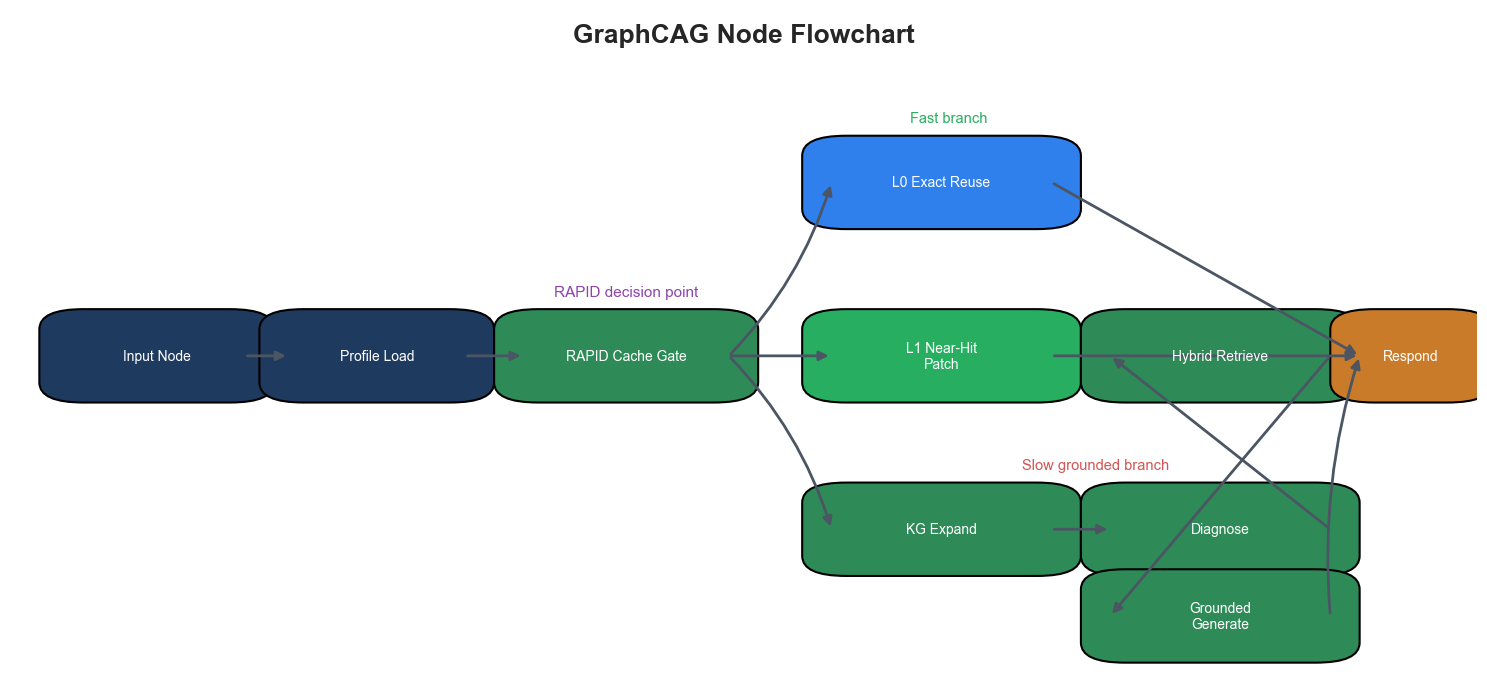

,case,cache_layer,decision,rho,latency_ms,note
0,Exact repeat,L0,reuse,0.250000,4,Exact normalized key hit.
1,Whitespace drift,L1,patch,0.250007,5,"L0 miss, graph bucket match, safe patch."
2,Intent shift,none,full,1.000000,69,PCC rejects reuse because intent drift is unsafe.


In [12]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

node_layout = {
    'input': ((0.04, 0.43), 0.12, 0.10),
    'profile': ((0.19, 0.43), 0.12, 0.10),
    'cache_gate': ((0.35, 0.43), 0.14, 0.10),
    'l0': ((0.56, 0.69), 0.15, 0.10),
    'l1': ((0.56, 0.43), 0.15, 0.10),
    'kg_expand': ((0.56, 0.17), 0.15, 0.10),
    'diagnose': ((0.75, 0.17), 0.15, 0.10),
    'retrieve': ((0.75, 0.43), 0.15, 0.10),
    'generate': ((0.75, 0.04), 0.15, 0.10),
    'respond': ((0.92, 0.43), 0.07, 0.10),
}

label_map = {node_id: label for node_id, label, _ in pipeline_nodes}
group_map = {node_id: group for node_id, _, group in pipeline_nodes}

for node_id, ((x, y), w, h) in node_layout.items():
    rounded_box(
        ax,
        (x, y),
        w,
        h,
        fill(label_map[node_id], 16),
        COLORS.get(group_map[node_id], COLORS['neutral']),
        fontsize=10
    )

connections = [
    ('input', 'profile'),
    ('profile', 'cache_gate'),
    ('cache_gate', 'l0'),
    ('cache_gate', 'l1'),
    ('cache_gate', 'kg_expand'),
    ('kg_expand', 'diagnose'),
    ('diagnose', 'retrieve'),
    ('retrieve', 'generate'),
    ('l0', 'respond'),
    ('l1', 'respond'),
    ('generate', 'respond'),
]

for src, dst in connections:
    (sx, sy), sw, sh = node_layout[src]
    (dx, dy), dw, dh = node_layout[dst]
    start = (sx + sw, sy + sh / 2) if sx <= dx else (sx, sy + sh / 2)
    end = (dx, dy + dh / 2) if sx <= dx else (dx + dw, dy + dh / 2)
    if src == 'cache_gate' and dst in {'l0', 'kg_expand'}:
        start = (sx + sw, sy + sh / 2)
        end = (dx, dy + dh / 2)
        rad = 0.0 if dst == 'l1' else (0.12 if dst == 'l0' else -0.12)
        arrow(ax, start, end, color='#4b5563', lw=2.0, connectionstyle=f'arc3,rad={rad}')
    elif src in {'retrieve', 'generate'} and dst == 'respond':
        start = (sx + sw, sy + sh / 2)
        end = (dx, dy + dh / 2)
        rad = -0.10 if src == 'generate' else 0.0
        arrow(ax, start, end, color='#4b5563', lw=2.0, connectionstyle=f'arc3,rad={rad}')
    else:
        arrow(ax, start, end, color='#4b5563', lw=2.0)

ax.text(0.5, 0.95, 'GraphCAG Node Flowchart', fontsize=19, fontweight='bold', ha='center')
ax.text(0.42, 0.57, 'RAPID decision point', fontsize=11, color=COLORS['accent'], ha='center')
ax.text(0.64, 0.83, 'Fast branch', fontsize=10.5, color=COLORS['l1'], ha='center')
ax.text(0.74, 0.31, 'Slow grounded branch', fontsize=10.5, color=COLORS['l2'], ha='center')
plt.tight_layout()
plt.show()

if pd is not None:
    display(trace_df[['case', 'cache_layer', 'decision', 'rho', 'latency_ms', 'note']])

## 2.6 Sample Request Traces Through the Nodes

The next figure injects sample requests into the flowchart. Each row is a realistic GraphCAG case with a different routing outcome:

- exact repeat -> L0 reuse,
- benign surface drift -> L1 patch,
- unsafe intent drift -> L2 grounded reconstruction.

This is the closest GraphCAG analogue to the traversal explanation in the GraphRAG notebook: instead of traversing knowledge nodes, we traverse **controller nodes**.

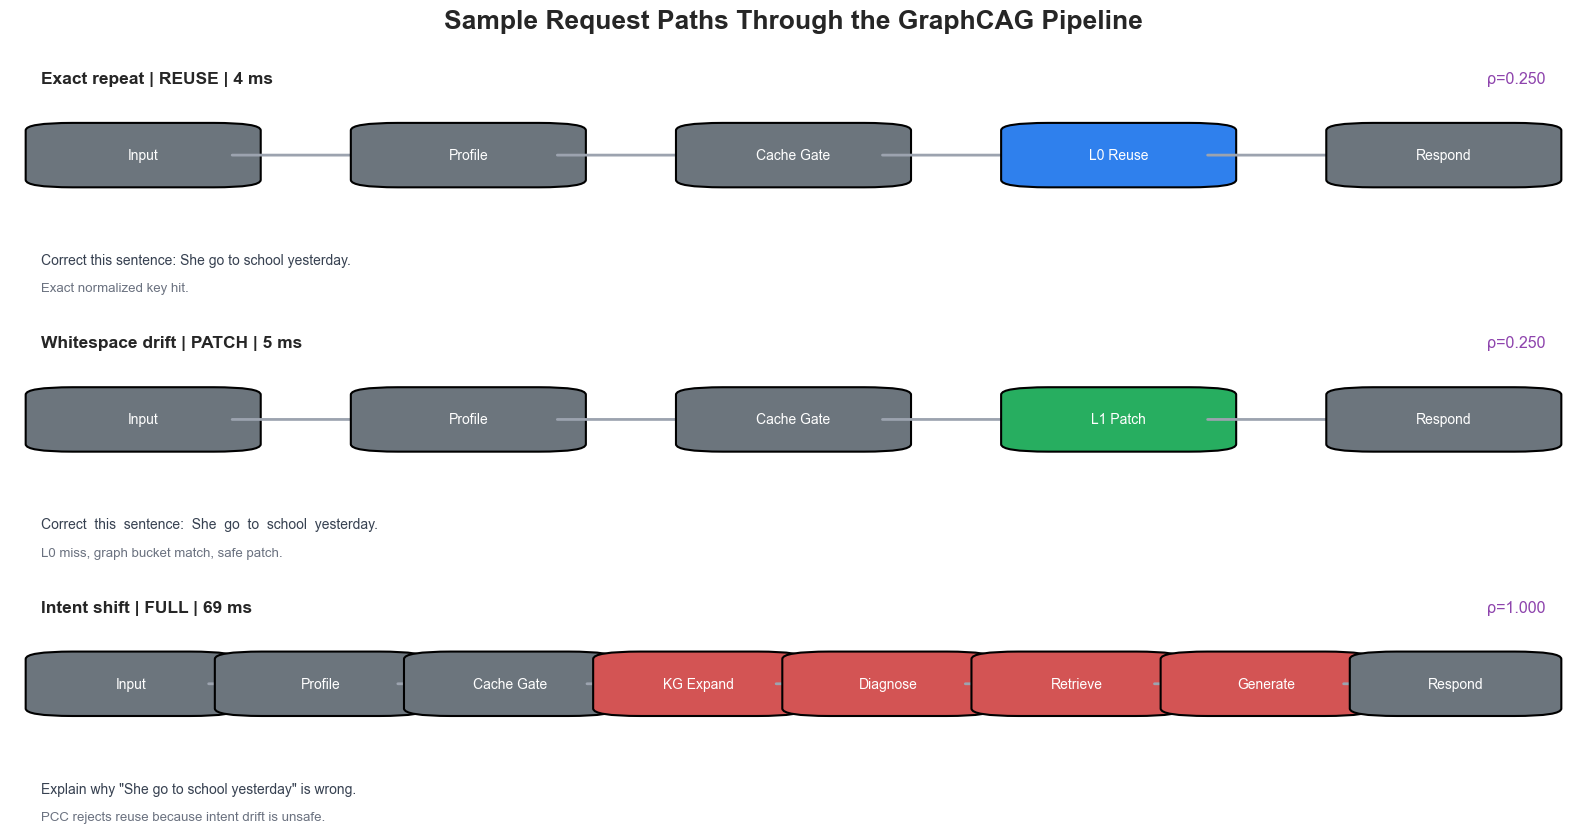

,node,state_update,sample_value
0,input,"user_input, session_id, input_type",B1 correction request
1,profile,"learner_profile, conversation_history","level=B1, sessions_completed=12"
2,cache_gate,"cache_fingerprint, cache_decision, cache_layer...","intent=unknown, bucket=sv_agreement|B1"
3,kg_expand,"kg_seed_concepts, kg_expanded_nodes","subject_verb_agreement, past_tense_marker"
4,diagnose,"diagnosis_intent, diagnosis_errors, diagnosis_...","correct, tense+agreement, 0.94"
5,retrieve,"retrieved_context, retrieval_trace",grammar snippets + examples
6,generate,"tutor_response, strategy, overall_score",scaffolded correction response
7,respond,"latency_ms, path, models_used",fast or slow response path


In [13]:
fig, axes = plt.subplots(len(sample_traces), 1, figsize=(16, 8.5))

node_name_map = {
    'input': 'Input',
    'profile': 'Profile',
    'cache_gate': 'Cache Gate',
    'l0': 'L0 Reuse',
    'l1': 'L1 Patch',
    'kg_expand': 'KG Expand',
    'diagnose': 'Diagnose',
    'retrieve': 'Retrieve',
    'generate': 'Generate',
    'respond': 'Respond',
}

for ax, trace in zip(axes, sample_traces):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    nodes = trace['path_nodes']
    n = len(nodes)
    left = 0.03
    right = 0.97
    width = 0.11 if n <= 5 else 0.095
    gap = (right - left - n * width) / max(n - 1, 1)
    y = 0.48
    h = 0.22

    for idx, node in enumerate(nodes):
        x = left + idx * (width + gap)
        if node == 'l0':
            fc = COLORS['l0']
        elif node == 'l1':
            fc = COLORS['l1']
        elif node in {'kg_expand', 'diagnose', 'retrieve', 'generate'}:
            fc = COLORS['l2']
        else:
            fc = COLORS['neutral']
        rounded_box(ax, (x, y), width, h, node_name_map[node], fc, fontsize=10)
        if idx < n - 1:
            next_x = left + (idx + 1) * (width + gap)
            arrow(ax, (x + width, y + h / 2), (next_x, y + h / 2), color='#9ca3af', lw=2.0)

    ax.text(0.02, 0.88, f"{trace['case']} | {trace['decision'].upper()} | {trace['latency_ms']} ms", fontsize=12.5, fontweight='bold', ha='left')
    ax.text(0.98, 0.88, f"ρ={trace['rho']:.3f}", fontsize=11.5, ha='right', color=COLORS['accent'])
    ax.text(0.02, 0.15, fill(trace['query'], 130), fontsize=10, color='#374151')
    ax.text(0.02, 0.04, trace['note'], fontsize=9.5, color='#6b7280')

fig.suptitle('Sample Request Paths Through the GraphCAG Pipeline', fontsize=19, fontweight='bold', y=0.985)
plt.tight_layout()
plt.show()

if pd is not None:
    display(state_df)

## 3. What State Flows Through the Pipeline

GraphCAG is easier to reason about when the pipeline state is grouped instead of read as a long typed dictionary. The controller is not routing on text alone. It carries learner context, graph evidence, diagnosis output, cache metadata, and final response traces in one evolving object.

In [ ]:
group_names = list(state_groups.keys())
group_sizes = [len(fields) for fields in state_groups.values()]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.1, 1.4]})
axes[0].barh(group_names, group_sizes, color=['#3b82f6', '#2563eb', '#0f766e', '#16a34a', '#f59e0b', '#ef4444', '#8b5cf6', '#14b8a6', '#6b7280'])
axes[0].set_title('State Schema by Group')
axes[0].set_xlabel('Field count')
axes[0].invert_yaxis()

axes[1].axis('off')
y = 0.98
for group, fields in state_groups.items():
    field_text = ', '.join(fields)
    axes[1].text(0.0, y, f'{group}:', fontsize=12, fontweight='bold', va='top')
    axes[1].text(0.25, y, fill(field_text, 60), fontsize=10.5, va='top')
    y -= 0.105

axes[1].set_title('Grouped View of GraphCAGState')
plt.tight_layout()
plt.show()

## 4. Why PCC and Reuse Risk Matter

The paper's central claim is that safe reuse under drift cannot be decided by lexical overlap alone. PCC turns reuse into an admissibility test over the active request-state tuple.

The scalar reuse risk is a weighted combination of five factors. This is the bridge between theory and an executable controller: the controller can rank or reject candidates before paying L2 cost.

In [ ]:
labels = [item[0] for item in risk_components]
weights = [item[1] for item in risk_components]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(labels, weights, color=['#ef4444', '#f97316', '#eab308', '#22c55e', '#3b82f6'])
axes[0].set_ylim(0, 0.35)
axes[0].set_title('Reuse Risk Weighting in PCC')
axes[0].set_ylabel('Weight')
axes[0].tick_params(axis='x', rotation=35)

axes[1].axis('off')
formula = 'ρ = clip[0,1](0.30·ΔI + 0.25·ΔC + 0.20·Δℓ + 0.10·Δprog + 0.15·s)'
axes[1].text(0.02, 0.80, 'Interpretation', fontsize=14, fontweight='bold')
axes[1].text(0.02, 0.64, fill(formula, 42), fontsize=16, color=COLORS['accent'])
axes[1].text(0.02, 0.42, fill('Low ρ means the candidate still looks admissible under the current state. High ρ means drift is large enough that the controller should reject reuse and fall through to L2.', 52), fontsize=12)
axes[1].text(0.02, 0.16, fill('This is what makes GraphCAG richer than exact-match CAG: reuse depends on state-sensitive safety, not only on text identity.', 52), fontsize=12)
plt.tight_layout()
plt.show()

## 5. Stage 1.5 Drift Probes: Where L0, L1, and L2 Actually Fire

The most compact way to understand GraphCAG is to look at probe cases. These are small, controlled perturbations of a cached request. They answer three questions:

- Which cases stay in L0?
- Which cases move into L1 patching?
- Which cases are unsafe enough to force L2 reconstruction?

In [ ]:
x = [item['rho'] for item in probe_results]
y = [item['latency_ms'] for item in probe_results]
colors = [COLORS['l0'] if item['layer'] == 'L0' else COLORS['l1'] if item['layer'] == 'L1' else COLORS['l2'] for item in probe_results]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(x, y, s=160, c=colors, edgecolor='black', alpha=0.9)
for item in probe_results:
    axes[0].annotate(item['probe'].replace('_variant', '').replace('_', ' '), (item['rho'], item['latency_ms']), xytext=(6, 6), textcoords='offset points', fontsize=9)
axes[0].set_title('Probe Routing: Reuse Risk vs Latency')
axes[0].set_xlabel('Reuse risk ρ')
axes[0].set_ylabel('Latency (ms)')
axes[0].axvline(0.55, color=COLORS['neutral'], linestyle='--', linewidth=1.5, label='illustrative L1 safety threshold')
axes[0].legend()

probe_names = [item['probe'].replace('_variant', '').replace('_', ' ') for item in probe_results]
probe_lat = [item['latency_ms'] for item in probe_results]
axes[1].barh(probe_names, probe_lat, color=colors)
axes[1].set_title('Latency by Probe')
axes[1].set_xlabel('Latency (ms)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

if pd is not None:
    display(pd.DataFrame(probe_results))
else:
    for row in probe_results:
        print(row)

## 6. Stage 1 Workload Efficiency View

The deterministic Stage 1 benchmark is not the whole GraphCAG story, but it makes one thing concrete: conservative reuse already cuts orchestration overhead materially. Stage 1.5 then explains *why* a richer controller matters, because it shows where near-hit reuse becomes visible.

In [ ]:
workloads = [item['workload'] for item in workload_benchmarks]
baseline = [item['baseline_ms'] for item in workload_benchmarks]
graphcag = [item['graphcag_ms'] for item in workload_benchmarks]
gains = [round((b - g) / b * 100, 1) for b, g in zip(baseline, graphcag)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
xpos = range(len(workloads))
width = 0.36
axes[0].bar([x - width / 2 for x in xpos], baseline, width=width, color=COLORS['l2'], label='No-cache baseline')
axes[0].bar([x + width / 2 for x in xpos], graphcag, width=width, color=COLORS['l0'], label='GraphCAG measured path')
axes[0].set_xticks(list(xpos))
axes[0].set_xticklabels(workloads, rotation=20)
axes[0].set_ylabel('Mean latency (ms)')
axes[0].set_title('Stage 1 Deterministic Workloads')
axes[0].legend()

axes[1].bar(workloads, gains, color=COLORS['l1'])
axes[1].set_title('Relative Overhead Reduction')
axes[1].set_ylabel('Reduction (%)')
axes[1].set_ylim(0, max(gains) + 10)
for idx, value in enumerate(gains):
    axes[1].text(idx, value + 1, f'{value}%', ha='center', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

if pd is not None:
    summary_df = pd.DataFrame(workload_benchmarks)
    summary_df['reduction_pct'] = gains
    display(summary_df)

## 7. Staged Evaluation Ladder

The paper now frames GraphCAG as a staged benchmark program. This helps readers avoid one common mistake: expecting Stage 1 latency tables alone to prove the whole framework. The stages have different jobs.

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

x_positions = [0.03, 0.28, 0.53, 0.78]
colors = [COLORS['l0'], COLORS['l1'], COLORS['core'], COLORS['accent']]
for (stage, title, desc), x0, color in zip(stage_summary, x_positions, colors):
    rounded_box(ax, (x0, 0.25), 0.19, 0.45, fill(f'{stage}\n{title}\n\n{desc}', 22), color, fontsize=10)

for i in range(len(x_positions) - 1):
    arrow(ax, (x_positions[i] + 0.19, 0.475), (x_positions[i + 1], 0.475), color='#333333')

ax.text(0.5, 0.86, 'GraphCAG Evaluation Ladder', ha='center', fontsize=18, fontweight='bold')
ax.text(0.5, 0.11, 'Stage 1 proves the executable lower bound. Stage 1.5 proves the central near-hit mechanism. Later stages scale coverage and richer reusable units.', ha='center', fontsize=11)
plt.show()

## 8. Compact Walkthrough Cases

A reviewer or teammate often only needs three cases to internalize the controller:

- **Exact repeat**: nothing material changed, so stop at L0.
- **Benign surface drift**: text changed a little, but graph-local state still matches, so patch at L1.
- **Unsafe drift**: intent or level changed enough that reuse must be rejected and L2 must rebuild context.

In [ ]:
walkthrough_cases = [
    {
        'case': 'Exact repeat',
        'fingerprint': 'same normalized query + same level',
        'bucket': 'not needed',
        'decision': 'L0 reuse',
        'why': 'Exact key hit; PCC exact checks pass; fastest safe path.'
    },
    {
        'case': 'Whitespace / punctuation drift',
        'fingerprint': 'same intent + level + concept seed',
        'bucket': 'same graph neighborhood bucket',
        'decision': 'L1 patch',
        'why': 'L0 misses, but graph-aware bucket lookup retrieves a safe near-hit with low ρ.'
    },
    {
        'case': 'Intent or level shift',
        'fingerprint': 'drifted intent / profile state',
        'bucket': 'candidate may exist but fails PCC',
        'decision': 'L2 full reconstruction',
        'why': 'Unsafe reuse risk is high; the controller must rebuild grounded context.'
    },
]

if pd is not None:
    display(pd.DataFrame(walkthrough_cases))
else:
    for case in walkthrough_cases:
        print(case)

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

positions = [0.04, 0.37, 0.70]
colors = [COLORS['l0'], COLORS['l1'], COLORS['l2']]
for idx, case in enumerate(walkthrough_cases):
    text = f"{case['case']}\n\nFingerprint: {case['fingerprint']}\nBucket: {case['bucket']}\nDecision: {case['decision']}\n\n{case['why']}"
    rounded_box(ax, (positions[idx], 0.18), 0.24, 0.56, fill(text, 24), colors[idx], fontsize=10)

ax.text(0.5, 0.86, 'Three Minimal Cases That Explain GraphCAG', ha='center', fontsize=18, fontweight='bold')
plt.show()

## Takeaway

This notebook turns the paper into a controller view:

- GraphCAG is not just graph retrieval. It is a **hierarchical reuse policy under drift**.
- L0 shows the conservative CAG-compatible fast path.
- L1 is where graph structure first changes the reuse decision.
- L2 remains the grounded safety net when reuse is absent or unsafe.

If you want to extend this notebook later, the next useful additions would be: a real import from the benchmark outputs, an interactive drift-case explorer, and a figure that overlays GraphCAG, vanilla CAG, and HippoRAG-style proxy modes in one comparison panel.